In [47]:
#celda 1

import pandas as pd
import matplotlib.pyplot as plt
import nltk

In [48]:
#celda 2
total_df = pd.read_csv('df_total.csv')
total_df.info()

print()
cantidad_documentos = total_df.shape[0]

print(f"El corpus tiene {cantidad_documentos} documentos.")
print("Columnas del corpus:", total_df.columns.tolist())
total_df.head()



<class 'pandas.DataFrame'>
RangeIndex: 1217 entries, 0 to 1216
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   url     1217 non-null   str  
 1   news    1217 non-null   str  
 2   Type    1217 non-null   str  
dtypes: str(3)
memory usage: 28.7 KB

El corpus tiene 1217 documentos.
Columnas del corpus: ['url', 'news', 'Type']


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


**¿Cuántos documentos tiene el corpus?**

El corpus tiene 1217 documentos.

**¿Qué columnas contiene y qué información guarda cada una?**

url: enlace a la noticia original.

news: texto completo de la noticia.

Type: categoría/etiqueta asignada a la noticia.

In [49]:
#celda 3
print("Cantidad de categorías:", total_df['Type'].nunique())
print()
print("Distribución:")
print(total_df['Type'].value_counts())
print()
print("Distribución (%):")
print((total_df['Type'].value_counts(normalize=True) * 100).round(2))

Cantidad de categorías: 7

Distribución:
Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

Distribución (%):
Type
Macroeconomia     27.94
Alianzas          20.30
Innovacion        16.02
Regulaciones      11.67
Sostenibilidad    11.26
Otra              10.68
Reputacion         2.14
Name: proportion, dtype: float64


In [50]:
#celda 4
print("Filas totalmente duplicadas:", total_df.duplicated().sum())
print("News (texto) duplicado:", total_df.duplicated(subset='news').sum())
print()
print("Valores nulos por columna:")
print(total_df.isnull().sum())
print()
print("Filas con texto vacío en news:", (total_df['news'].str.strip() == '').sum())

Filas totalmente duplicadas: 75
News (texto) duplicado: 79

Valores nulos por columna:
url     0
news    0
Type    0
dtype: int64

Filas con texto vacío en news: 4


**¿Cuántas categorías hay y cómo se distribuyen?**

El corpus tiene 7 categorías: Macroeconomia, Alianzas, 
Innovación, Regulaciones, Sostenibilidad, Otra y Reputación. No están nada balanceadas, solo macroeconomía tiene 
casi 3 veces más noticias que Regulaciones o Sostenibilidad, y Reputacion es casi indiferente, ya que es bastante pequeña comparada con las demás.

**¿Hay filas vacías o duplicadas?**

Sí, hay 75 filas duplicadas y 79 noticias con el mismo texto, aunque no coincidan exactamente todas las columnas. No hay valores nulos en ninguna columna, pero sí hay 4 filas donde el texto de la noticia está vacío.

In [51]:
#celda 5
total_df = total_df.drop_duplicates(subset='news').dropna(subset=['news']).reset_index(drop=True)
print(f"limpió {total_df.shape[0]} datos")


limpió 1138 datos


In [52]:
#celda 6
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

resumen_pipeline = []

def contar_tokens_tipos(serie_de_listas):
    tokens = [t for doc in serie_de_listas for t in doc]
    tipos = set(tokens)
    return len(tokens), len(tipos)

# i. Tokenización
total_df['tok'] = total_df['news'].apply(lambda x: word_tokenize(x, language='spanish'))
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Tokenización', n_tok, n_tip))
print(f"Tokenización: {n_tok} tokens, {n_tip} tipos")

# ii. Minúsculas
total_df['tok'] = total_df['tok'].apply(lambda toks: [t.lower() for t in toks])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Minúsculas', n_tok, n_tip))
print(f"Minúsculas: {n_tok} tokens, {n_tip} tipos")

# iii. Eliminar puntuación
puntuacion = set(string.punctuation + '¿¡""''—…')
total_df['tok'] = total_df['tok'].apply(
    lambda toks: [t for t in toks if t not in puntuacion and any(c.isalnum() for c in t)]
)
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin puntuación', n_tok, n_tip))
print(f"Sin puntuación: {n_tok} tokens, {n_tip} tipos")

# iv. Eliminar stopwords
stop_es = set(stopwords.words('spanish'))
total_df['tok'] = total_df['tok'].apply(lambda toks: [t for t in toks if t not in stop_es])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Sin stopwords', n_tok, n_tip))
print(f"Sin stopwords: {n_tok} tokens, {n_tip} tipos")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/luispegr25/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tokenización: 631481 tokens, 39017 tipos
Minúsculas: 631481 tokens, 36178 tipos
Sin puntuación: 598368 tokens, 36142 tipos
Sin stopwords: 318949 tokens, 35931 tipos


In [53]:
#celda 7
import spacy
nlp = spacy.load('es_core_news_sm')

def lematizar_batch(lista_de_listas_tokens, batch_size=50):
    textos = [' '.join(toks) for toks in lista_de_listas_tokens]
    resultados = []
    for doc in nlp.pipe(textos, batch_size=batch_size):
        resultados.append([tok.lemma_ for tok in doc])
    return resultados

total_df['tok'] = lematizar_batch(total_df['tok'])
n_tok, n_tip = contar_tokens_tipos(total_df['tok'])
resumen_pipeline.append(('Lematizado', n_tok, n_tip))
print(f"Lematizado: {n_tok} tokens, {n_tip} tipos")

Lematizado: 319667 tokens, 28801 tipos


In [54]:
#celda 8
resumen_df = pd.DataFrame(resumen_pipeline, columns=['Paso', 'Tokens', 'Tipos'])
tipos_original = resumen_df.loc[0, 'Tipos']
resumen_df['% reducción tipos vs original'] = ((tipos_original - resumen_df['Tipos']) / tipos_original * 100).round(2)
resumen_df

,Paso,Tokens,Tipos,% reducción tipos vs original
0,Tokenización,631481,39017,0.00
1,Minúsculas,631481,36178,7.28
2,Sin puntuación,598368,36142,7.37
3,Sin stopwords,318949,35931,7.91
4,Lematizado,319667,28801,26.18


### ¿Qué es un EDA?

Un Análisis Exploratorio de Datos (EDA) es básicamente lo primero que uno tiene cuando están los datos antes de meterles cualquier modelo. Consiste en revisar el dataset con estadísticas descriptivas y gráficos para entender cómo está armado, cómo se distribuye la información, si hay  problemas de calidad y si hay algo raro o inesperados.

### ¿Qué busca lograr un EDA dentro de un proyecto de ciencia de datos?

Entender qué tan grande es el dataset y cómo está estructurado (por ejemplo cuántas filas, columnas, qué tipo de dato hay en cada una).


Encontrar problemas como valores nulos, filas duplicadas, outliers o cosas que no cuadran.


Detectar patrones o relaciones entre variables que después sirvan para decidir cómo modelar.


Armar hipótesis desde el principio, antes de empezar formalmente el modelado.


Decidir qué tipo de preprocesamiento hace falta (normalizar, transformar, elegir variables).


In [55]:
#celda 9
n_tokens_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tokens'].values[0]
n_tipos_final = resumen_df.loc[resumen_df['Paso']=='Lematizado', 'Tipos'].values[0]
ttr_global = n_tipos_final / n_tokens_final
print(f"TTR global (normalizado): {ttr_global:.4f}")

def ttr_por_categoria(df, col_tokens='tok', col_cat='Type'):
    filas = []
    for cat, grupo in df.groupby(col_cat):
        tokens = [t for lista in grupo[col_tokens] for t in lista]
        tipos = set(tokens)
        ttr = len(tipos)/len(tokens) if tokens else 0
        filas.append((cat, len(tokens), len(tipos), round(ttr, 4)))
    return pd.DataFrame(filas, columns=['Categoría','Tokens','Tipos','TTR'])

ttr_cat_df = ttr_por_categoria(total_df)
ttr_cat_df

TTR global (normalizado): 0.0901


,Categoría,Tokens,Tipos,TTR
0,Alianzas,48898,9956,0.2036
1,Innovacion,50846,7068,0.1390
2,Macroeconomia,93245,11895,0.1276
3,Otra,28357,5813,0.2050
4,Regulaciones,37162,8032,0.2161
5,Reputacion,7704,2702,0.3507
6,Sostenibilidad,53455,8252,0.1544


In [56]:
#celda 10
from collections import Counter

todos_tokens = [t for lista in total_df['tok'] for t in lista]
frecuencias = Counter(todos_tokens)

freq_df = pd.DataFrame(frecuencias.most_common(20), columns=['palabra', 'frecuencia'])
freq_df

,palabra,frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


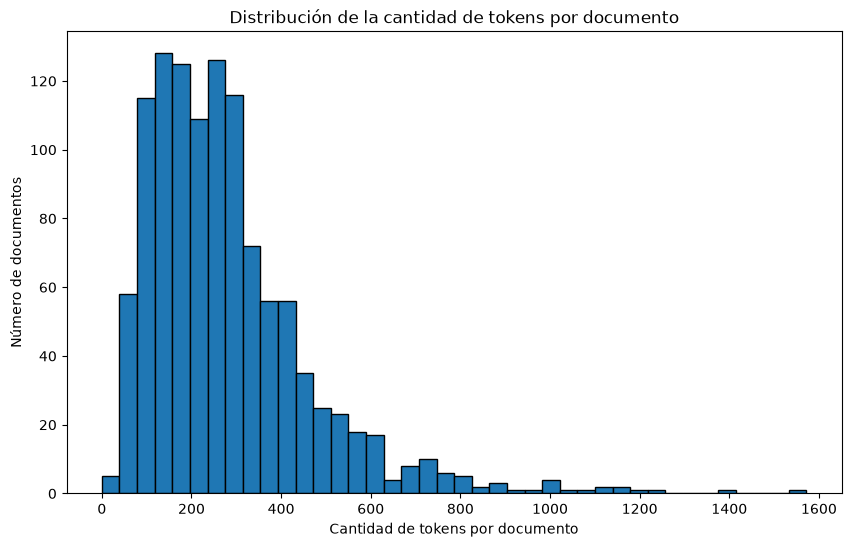

In [57]:
#celda 11
total_df['n_tokens_doc'] = total_df['tok'].apply(len)

plt.figure(figsize=(10, 6))
plt.hist(total_df['n_tokens_doc'], bins=40, edgecolor='black')
plt.xlabel('Cantidad de tokens por documento')
plt.ylabel('Número de documentos')
plt.title('Distribución de la cantidad de tokens por documento')
plt.show()

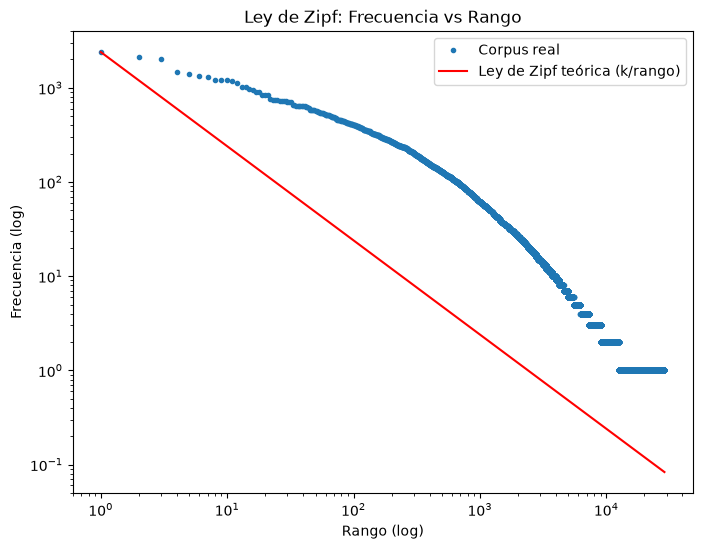

In [58]:
#celda 12
import numpy as np

frecs_ordenadas = sorted(frecuencias.values(), reverse=True)
rangos = np.arange(1, len(frecs_ordenadas) + 1)

k = frecs_ordenadas[0]
zipf_teorico = k / rangos

plt.figure(figsize=(8, 6))
plt.loglog(rangos, frecs_ordenadas, marker='.', linestyle='none', label='Corpus real')
plt.loglog(rangos, zipf_teorico, color='red', label='Ley de Zipf teórica (k/rango)')
plt.xlabel('Rango (log)')
plt.ylabel('Frecuencia (log)')
plt.title('Ley de Zipf: Frecuencia vs Rango')
plt.legend()
plt.show()

In [59]:
#celda 13
categorias_a_comparar = total_df['Type'].unique()[:2]  # cambia por las categorías que prefieras

for cat in categorias_a_comparar:
    subset = total_df[total_df['Type'] == cat]
    tokens_cat = [t for lista in subset['tok'] for t in lista]
    frec_cat = Counter(tokens_cat)
    print(f"\nTop 10 palabras — Categoría: {cat}")
    for palabra, freq in frec_cat.most_common(10):
        print(f"  {palabra}: {freq}")


Top 10 palabras — Categoría: Otra
  banco: 386
  bbva: 332
  millón: 275
  financiero: 217
  año: 206
  entidad: 195
  poder: 164
  crédito: 157
  cliente: 142
  tasa: 139

Top 10 palabras — Categoría: Regulaciones
  poder: 275
  decir: 233
  regulación: 230
  empresa: 220
  país: 214
  mercado: 185
  servicio: 173
  hacer: 171
  año: 170
  nuevo: 168


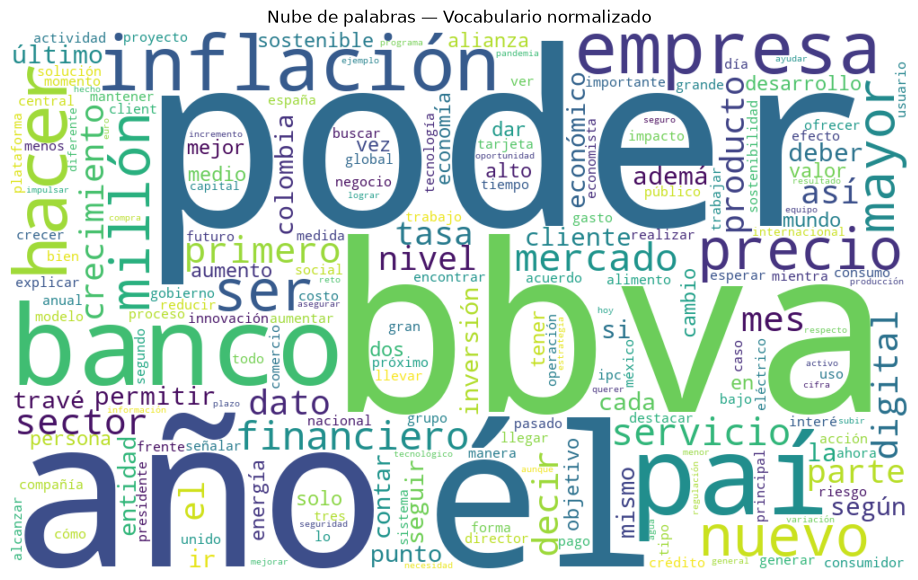

In [60]:
#celda 14
from wordcloud import WordCloud

texto_normalizado = ' '.join(todos_tokens)
wc = WordCloud(width=1000, height=600, background_color='white', collocations=False).generate(texto_normalizado)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras — Vocabulario normalizado')
plt.show()